## Setup

In [ ]:
using_colab = True

In [ ]:
pip install --upgrade "numpy<2.0" scipy opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.13.0.90-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)


In [ ]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
  Cloning https://github.com/facebookresearch/sam3.git to /tmp/pip-req-build-f7l1pibb
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam3.git /tmp/pip-req-build-f7l1pibb
  Resolved https://github.com/facebookresearch/sam3.git to commit 32f5f81ab9eef0ef3bd33be4d2af31e350ae64ef
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.6 MB/s eta 0:00:00
  Created wheel for sam3: filename=sam3-0.1.0-py3-none-any.whl size=2035252 sha256=517dacc06331887954be7c8c4c26c7296d295a60a5409d446070d4dd6414b6f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-fz7taqti/wheels/d0/2d/ba/135e3f5c76e53027dc9bfe15a474878249

In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!nvidia-smi

Fri May 15 21:59:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 113.0 MB/s eta 0:00:00


In [ ]:
import os
import sam3
import torch

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

# use all available GPUs on the machine
gpus_to_use = range(torch.cuda.device_count())
# # use only a single GPU
# gpus_to_use = [torch.cuda.current_device()]

/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
from sam3.model_builder import build_sam3_video_predictor

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

INFO 2026-05-15 21:59:45,267 15961 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-05-15 21:59:45,269 15961 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-15 21:59:45,271 15961 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-05-15 22:00:01,368 15961 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-05-15 22:00:55,899 15961 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-05-15 22:00:55,900 15961 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




In [ ]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

## Load a video

We assume that the video is stored as either **a list of JPEG frames with filenames like `<frame_index>.jpg`** or **an MP4 video**.

Note that you can extract their JPEG frames using ffmpeg (https://ffmpeg.org/) as follows:
```
ffmpeg -i <your_video>.mp4 -q:v 2 -start_number 0 <output_dir>/'%05d.jpg'
```
where `-q:v` generates high-quality JPEG frames and `-start_number 0` asks ffmpeg to start the JPEG file from `00000.jpg`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# "video_path" needs to be either a JPEG folder or a MP4 video file
video_path = f"/content/drive/MyDrive/TFG/Press/Vid/bench_press_10.mp4"

In [ ]:
# load "video_frames_for_vis" for visualization purposes (they are not used by the model)
if isinstance(video_path, str) and video_path.endswith(".mp4"):
    cap = cv2.VideoCapture(video_path)
    video_frames_for_vis = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
else:
    video_frames_for_vis = glob.glob(os.path.join(video_path, "*.jpg"))
    try:
        # integer sort instead of string sort (so that e.g. "2.jpg" is before "11.jpg")
        video_frames_for_vis.sort(
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
    except ValueError:
        # fallback to lexicographic sort if the format is not "<frame_index>.jpg"
        print(
            f'frame names are not in "<frame_index>.jpg" format: {video_frames_for_vis[:5]=}, '
            f"falling back to lexicographic sort."
        )
        video_frames_for_vis.sort()

### Opening an inference session on this video

SAM 3 requires stateful inference for interactive video segmentation, so we need to initialize an **inference session** on this video.

During initialization, it loads all the video frames and stores their pixels in the session state.

In [ ]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_path,
    )
)
session_id = response["session_id"]

frame loading (OpenCV) [rank=0]: 100%|██████████| 53/53 [00:00<00:00, 89.27it/s]
INFO 2026-05-15 22:01:47,889 15961 sam3_base_predictor.py: 146: started new session 8070727d-967e-4f22-ba05-7deda94202c3


### Video promptable concept segmentation with text

Using SAM 3 you can describe objects using natural language, and the model will automatically detect and track all instances of that object throughout the video.

In the example below, we add a text prompt on frame 0 and propagation throughout the video. Here we use the text prompt "person" to detect all people in the video. SAM 3 will automatically identify multiple person instances and assign each a unique object ID.

Note that the first call might be slower due to setting up buffers. **You can rerun all the cells below when measuring speed.**

In [ ]:
# note: in case you already ran one text prompt and now want to switch to another text prompt
# it's required to reset the session first (otherwise the results would be wrong)
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

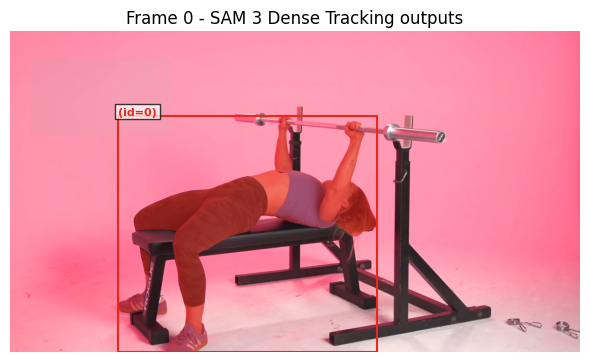

In [ ]:
prompt_text_str = "person"
frame_idx = 0  # add a text prompt on frame 0
response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt_text_str,
    )
)
out = response["outputs"]

if "out_obj_ids" in out and len(out["out_obj_ids"]) > 1:
    print(f"⚠️ We found {len(out['out_obj_ids'])} objects. Filtering...")

    # We robustly calculate the area of ​​each mask
    # We iterate through each mask in the list/tensor and sum its pixels
    areas = [m.sum() for m in out["out_binary_masks"]]

    # Encontramos el índice de la posición con el valor máximo
    idx_max = areas.index(max(areas))

    # We cut out the objects to leave only the main one.
    out["out_obj_ids"] = out["out_obj_ids"][idx_max : idx_max + 1]
    out["out_binary_masks"] = out["out_binary_masks"][idx_max : idx_max + 1]

    if "out_mask_logits" in out:
        out["out_mask_logits"] = out["out_mask_logits"][idx_max : idx_max + 1]

    print(f"✅ Selecting the biggest object (Area: {int(max(areas))} px)")

    predictor.handle_request(dict(type="reset_session", session_id=session_id))
    response = predictor.handle_request(dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt_text_str
    ))

    # We update 'out' with the response from the clean session
    out = response["outputs"]

    # One last check in case the new prompt detects noise again
    if len(out["out_obj_ids"]) > 1:
        new_areas = [m.sum() for m in out["out_binary_masks"]]
        i_m = new_areas.index(max(new_areas))
        out["out_obj_ids"] = out["out_obj_ids"][i_m : i_m + 1]
        out["out_binary_masks"] = out["out_binary_masks"][i_m : i_m + 1]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
)

propagate_in_video:   0%|          | 0/53 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-05-15 22:05:46,147 15961 sam3_base_predictor.py: 305: propagation ended in session 8070727d-967e-4f22-ba05-7deda94202c3


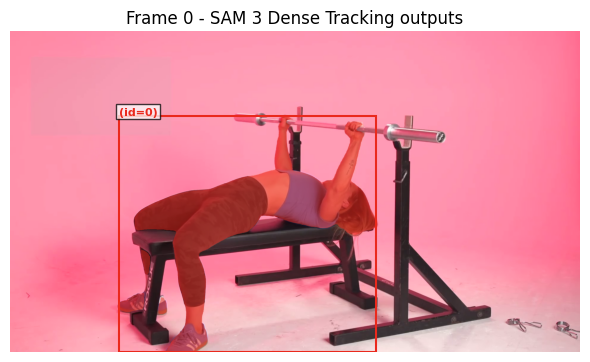

Recording video in: /content/drive/MyDrive/TFG/Press/Vid/bench_press_10_segmented.mp4...
✅ ¡Video exported succesfully!


In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# Beginning secondary subject cleanup
for f_idx in outputs_per_frame:
    frame_data = outputs_per_frame[f_idx]

    # we verify that it has the structure expected by prepare_masks_for_visualization
    if "out_obj_ids" in frame_data and "out_binary_masks" in frame_data:
        masks = frame_data["out_binary_masks"]

        # We calculate the areas of all objects in this frame
        areas = [m.sum().item() if hasattr(m, "sum") else 0 for m in masks]

        if len(areas) > 1:
            # We are looking for the index of the largest
            idx_max = areas.index(max(areas))

            frame_data["out_obj_ids"] = frame_data["out_obj_ids"][idx_max : idx_max + 1]
            frame_data["out_binary_masks"] = frame_data["out_binary_masks"][idx_max : idx_max + 1]

            if "out_mask_logits" in frame_data:
                frame_data["out_mask_logits"] = frame_data["out_mask_logits"][idx_max : idx_max + 1]

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

# we define the output path
output_video_path = "/content/drive/MyDrive/TFG/Press/Vid/bench_press_10_segmented.mp4"

# we use the path of the original video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# configuration of the output file
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

print(f"Recording video in: {output_video_path}...")

for frame_idx in range(len(outputs_per_frame)):
    ret, frame = cap.read()
    if not ret:
        break

    # if there is mask in this frame, we paint it
    if frame_idx in outputs_per_frame:
        frame_masks = outputs_per_frame[frame_idx]
        for obj_id, mask in frame_masks.items():
            # we convert the mask into image (0 or 255)
            mask_np = (mask.cpu().numpy() if hasattr(mask, "cpu") else np.array(mask)).astype(np.uint8)

            # if the mask does not coincide in size, we resize it
            if mask_np.shape[:2] != (h, w):
                mask_np = cv2.resize(mask_np, (w, h), interpolation=cv2.INTER_NEAREST)

            # we paint in blue where is located the mask
            overlay = frame.copy()
            overlay[mask_np > 0] = [255, 0, 0] # blue in BGR
            cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)

    out.write(frame)

cap.release()
out.release()
print("✅ ¡Video exported succesfully!")

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# 1. Definir ruta y asegurar que la carpeta existe
# He cambiado el nombre a 'Frames_Segmentados' para que sea una carpeta dedicada
ruta_frames_dir = "/content/drive/MyDrive/TFG/Press/Img/Segmented_Frames/bench_press_10"
os.makedirs(ruta_frames_dir, exist_ok=True)

print(f"🚀 Iniciando exportación de frames segmentados a: {ruta_frames_dir}")

# 2. Recorrer todos los frames cargados en 'video_frames_for_vis'
for i in tqdm(range(len(video_frames_for_vis)), desc="Procesando video"):

    # Obtener el frame original (ya está en RGB por tu código previo)
    frame = video_frames_for_vis[i]
    h, w = frame.shape[:2]

    # Crear la imagen de salida (empezamos con fondo negro)
    person_segmented = np.zeros_like(frame)

    # 3. Comprobar si hay máscara para este frame en 'outputs_per_frame'
    if i in outputs_per_frame:
        # outputs_per_frame[i] contiene un diccionario de {obj_id: mask_tensor}
        frame_masks = outputs_per_frame[i]

        # Creamos una máscara combinada por si hay varios objetos (o partes del cuerpo)
        mask_final = np.zeros((h, w), dtype=np.uint8)

        for obj_id, mask_tensor in frame_masks.items():
            # Convertir a numpy (tal como hiciste en el frame individual)
            if hasattr(mask_tensor, "cpu"):
                mask_np = mask_tensor.cpu().numpy()
            else:
                mask_np = np.array(mask_tensor)

            # Limpiar dimensiones (SAM 3 a veces devuelve 1, H, W o H, W)
            if mask_np.ndim > 2:
                mask_np = mask_np.squeeze() # Quita dimensiones extra de 1

            # Convertir a binario
            mask_binary = (mask_np > 0).astype("uint8")

            # Asegurar tamaño coincidente
            if mask_binary.shape[:2] != (h, w):
                mask_binary = cv2.resize(mask_binary, (w, h), interpolation=cv2.INTER_NEAREST)

            # Combinar con la máscara final del frame
            mask_final = cv2.bitwise_or(mask_final, mask_binary)

        # 4. Aplicar máscara: Copiar solo la persona al fondo negro
        person_segmented[mask_final > 0] = frame[mask_final > 0]

    # 5. Guardar el frame con nombre correlativo (0000, 0001, 0002...)
    # Usar 4 dígitos es vital para que el segundo Colab los lea en orden
    nombre_archivo = f"frame_{i:04d}.png"
    ruta_guardado = os.path.join(ruta_frames_dir, nombre_archivo)

    # Convertir de RGB a BGR para guardar con OpenCV
    cv2.imwrite(ruta_guardado, cv2.cvtColor(person_segmented, cv2.COLOR_RGB2BGR))

print(f"\n✅ ¡PROCESO COMPLETADO!")
print(f"Se han guardado {len(video_frames_for_vis)} imágenes en tu Drive.")

🚀 Iniciando exportación de frames segmentados a: /content/drive/MyDrive/TFG/Press/Img/Segmented_Frames/bench_press_10


Procesando video: 100%|██████████| 53/53 [01:57<00:00,  2.21s/it]


✅ ¡PROCESO COMPLETADO!
Se han guardado 53 imágenes en tu Drive.
